# Exploratory data Analysis (EDA)
-----------------------------------------------

#### ML Canvas
---------------------------------
---------------------------------
O objetivo deste projeto é identificar padrões que levam ao cancelamento de clientes (churn)
Stakeholders: Área de Marketing → campanhas de retenção, área de Customer Success → atuação preventiva,  área Financeira → redução de perda de receita
O dataset contém informações demográficas, dados de contrato,serviços contratados, informações financeiras, histórico de churn



In [46]:
import pandas as pd
import openpyxl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
df = pd.read_excel("../data/raw/Telco_customer_churn.xlsx")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [48]:
df.shape

(7043, 33)

### volume de dados inicial são 7043 linhas e 33 colunas

In [49]:
df.isnull().sum()
df.info()
df.duplicated().sum()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

### Tipos de dados encontrados no dataset

## Variavél alvo -> churn value

In [50]:
df["Churn Value"].value_counts()

Churn Value
0    5174
1    1869
Name: count, dtype: int64

In [51]:
df["Churn Value"].value_counts(normalize=True)

Churn Value
0    0.73463
1    0.26537
Name: proportion, dtype: float64

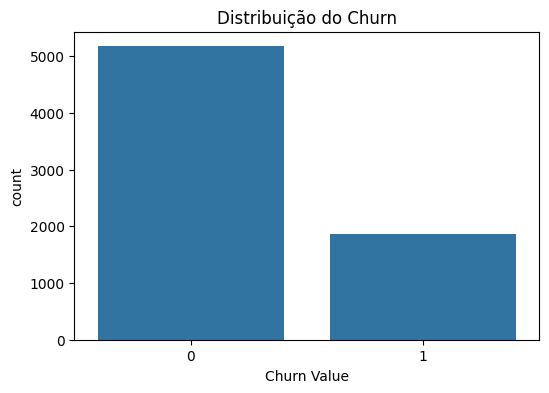

In [52]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn Value", data=df)
plt.title("Distribuição do Churn")
plt.show()

#### Podemos identificar um desbalanceamento moderado na proporção de churn dentro do dataset, aproximadamente 73% dos clientes não realizaram churn contra 27% que realizaram, esse desbalanceamento impacta na escolha de metricas apropriadas para o modelo e não apenas accuracy.

## Limpeza e preparação de dados

In [53]:
#coluna esta como object, mas deveria ser numerica para uso do modelo
df["Total Charges"].dtype

dtype('O')

In [54]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df["Total Charges"].dtype

dtype('float64')

### Eliminando colunas que trariam vazamentos (Leakage) para o modelo, essas colunas ja incluem os resultados que queremos prever com o modelo no futuro

In [55]:
#colunas que não são relevantes para a análise de churn e que trazem vazamentos/"spoilers" 
# para o modelo de machine learning colunas como churn label  ja nos trazem a resposta que nosso modelo ira trabalhar para buscar, por isso removemos ela
df = df.drop(columns=[
    "Churn Label",
    "Churn Score",
    "Churn Reason",
    "CLTV"
])

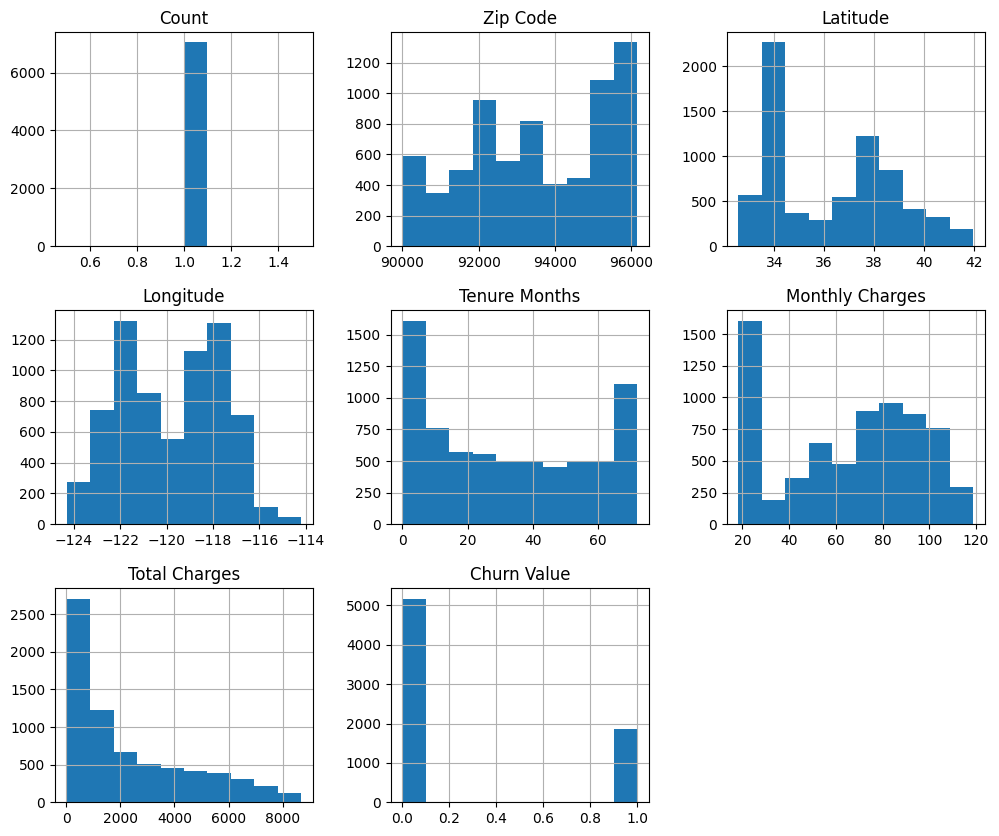

In [56]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols].hist(figsize=(12,10))
plt.show()

/tmp/ipykernel_5015/3136067334.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_churn = df.groupby("Monthly Charges Bin")["Churn Value"].mean()


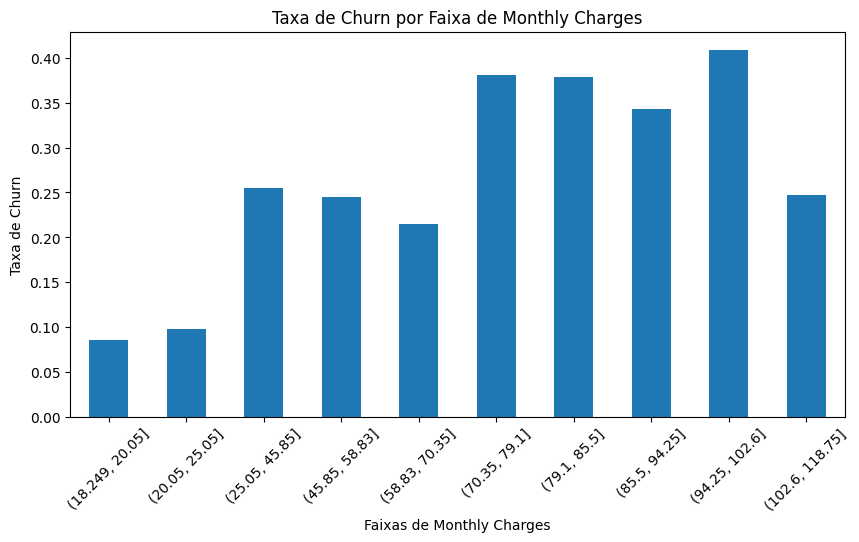

In [57]:
df["Monthly Charges Bin"] = pd.qcut(df["Monthly Charges"], q=10)
monthly_churn = df.groupby("Monthly Charges Bin")["Churn Value"].mean()

plt.figure(figsize=(10,5))
monthly_churn.plot(kind="bar")
plt.title("Taxa de Churn por Faixa de Monthly Charges")
plt.ylabel("Taxa de Churn")
plt.xlabel("Faixas de Monthly Charges")
plt.xticks(rotation=45)
plt.show()

#### Podemos observar que quanto maior a quantidade de cobranças mensais maior a taxa de churn é

/tmp/ipykernel_5015/819065317.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_churn = df.groupby("Total Charges Bin")["Churn Value"].mean()


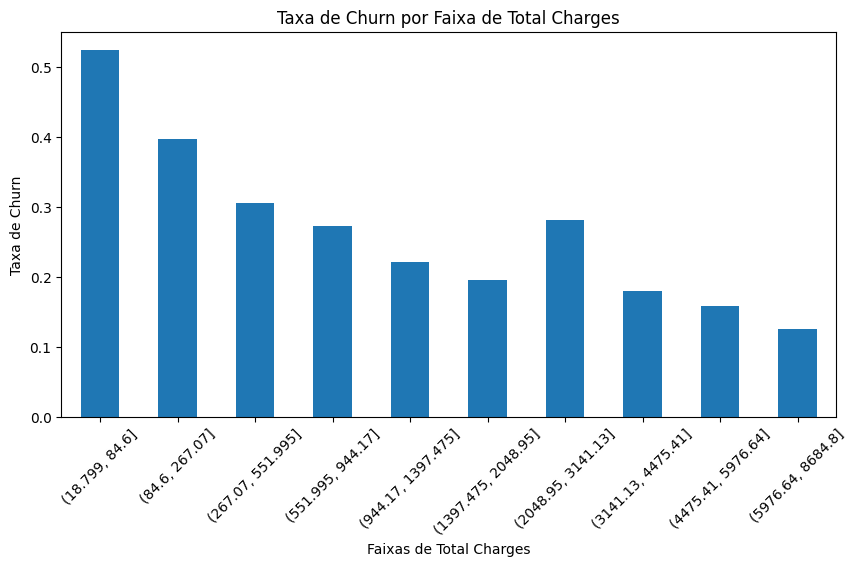

In [58]:
df["Total Charges Bin"] = pd.qcut(df["Total Charges"], q=10)
total_churn = df.groupby("Total Charges Bin")["Churn Value"].mean()

plt.figure(figsize=(10,5))
total_churn.plot(kind="bar")
plt.title("Taxa de Churn por Faixa de Total Charges")
plt.ylabel("Taxa de Churn")
plt.xlabel("Faixas de Total Charges")
plt.xticks(rotation=45)
plt.show()

#### Podemos observar que quanto menos cobranças totais temos maior é a taxa de churn, isso ocorre pois clientes por longos períodos de tempo são os clientes que não tendem a cancelar os serviços acumulam mais cobranças.

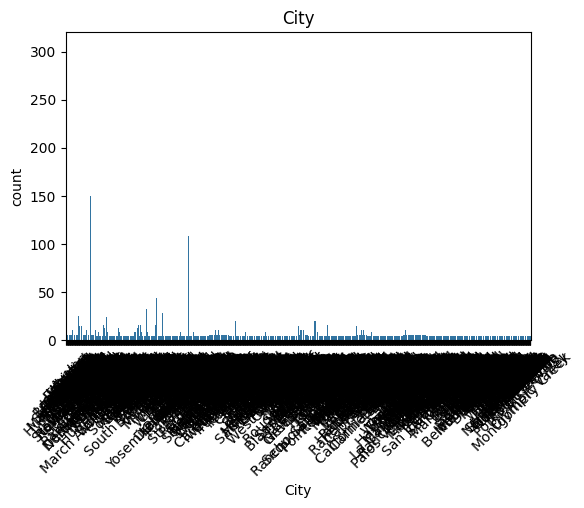

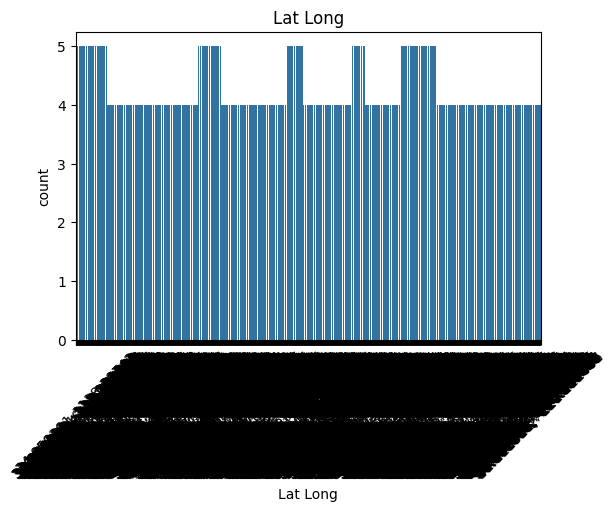

In [59]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols[3:5]:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

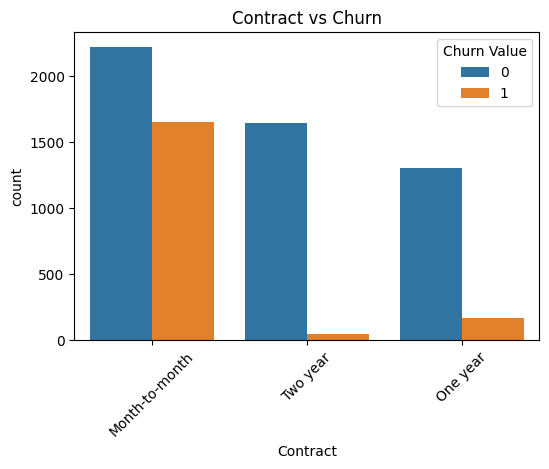

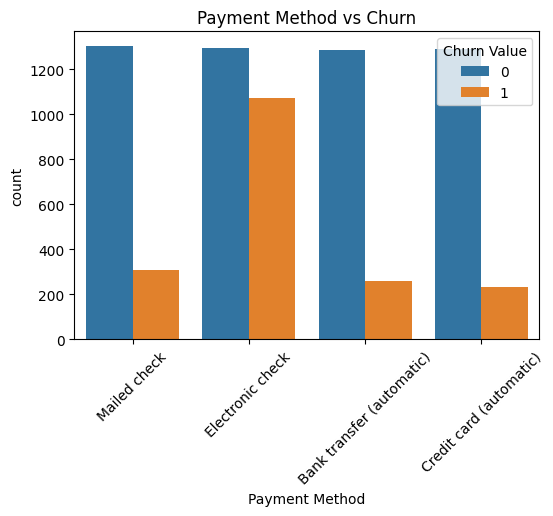

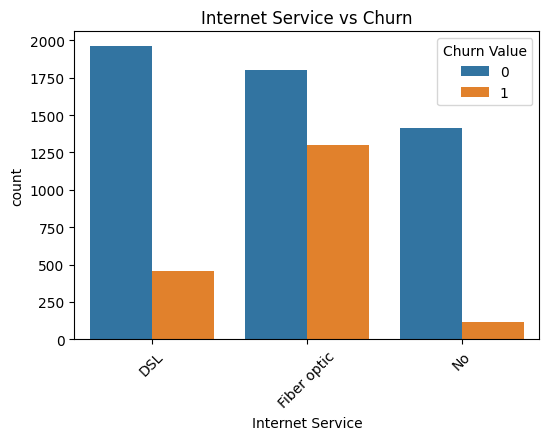

In [60]:
cols = ["Contract", "Payment Method", "Internet Service"]

for col in cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue="Churn Value")
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Churn")
    plt.show()

#### Podemos observar que quanto maior o tempo de contrato menos churn temos
#### Também vemos que o tipo de serviço de internet influência no churn clientes com fibra ótica tendem a cancelar mais
#### Assim como a forma de pagamento o seu respectivo gráfico de barras nos mostrou que clientes que recebem seus boletos de forma eletrônica são os que mais cancelam

In [61]:
pd.crosstab(df["Contract"], df["Churn Value"], normalize="index")

Churn Value,0,1
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


### Podemos observar que quanto maior é o tempo de contrato menor será a quantidade de clientes que realizam o churn, em contratos mensai temos uma distribuição levemente desbalanceada ja nos contratos anuais e bienais é fortemente desbalanceado onde mais de 88% dos clientes não cancelam

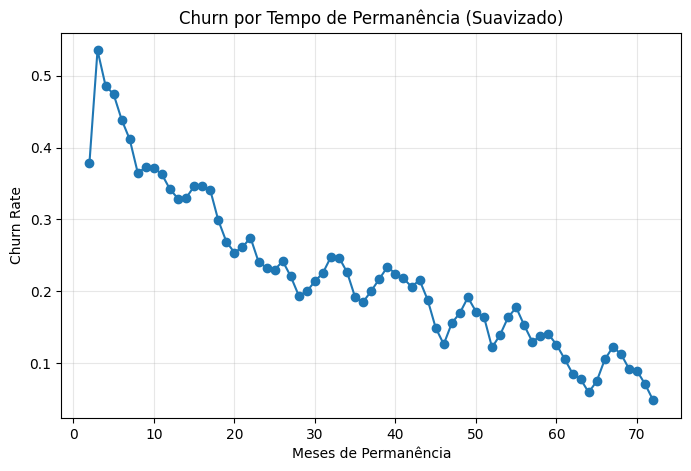

In [62]:
tenure_churn = df.groupby("Tenure Months")["Churn Value"].mean()

tenure_churn_smooth = tenure_churn.rolling(window=3).mean()

plt.figure(figsize=(8,5))
plt.plot(tenure_churn_smooth, marker='o')

plt.title("Churn por Tempo de Permanência (Suavizado)")
plt.xlabel("Meses de Permanência")
plt.ylabel("Churn Rate")

plt.grid(alpha=0.3)
plt.show()

### Podemos observar que a taxa de cancelamento reduz à medida que o tempo de relacionamento aumenta indicando que a retenção dos cliente é um fator crítico.

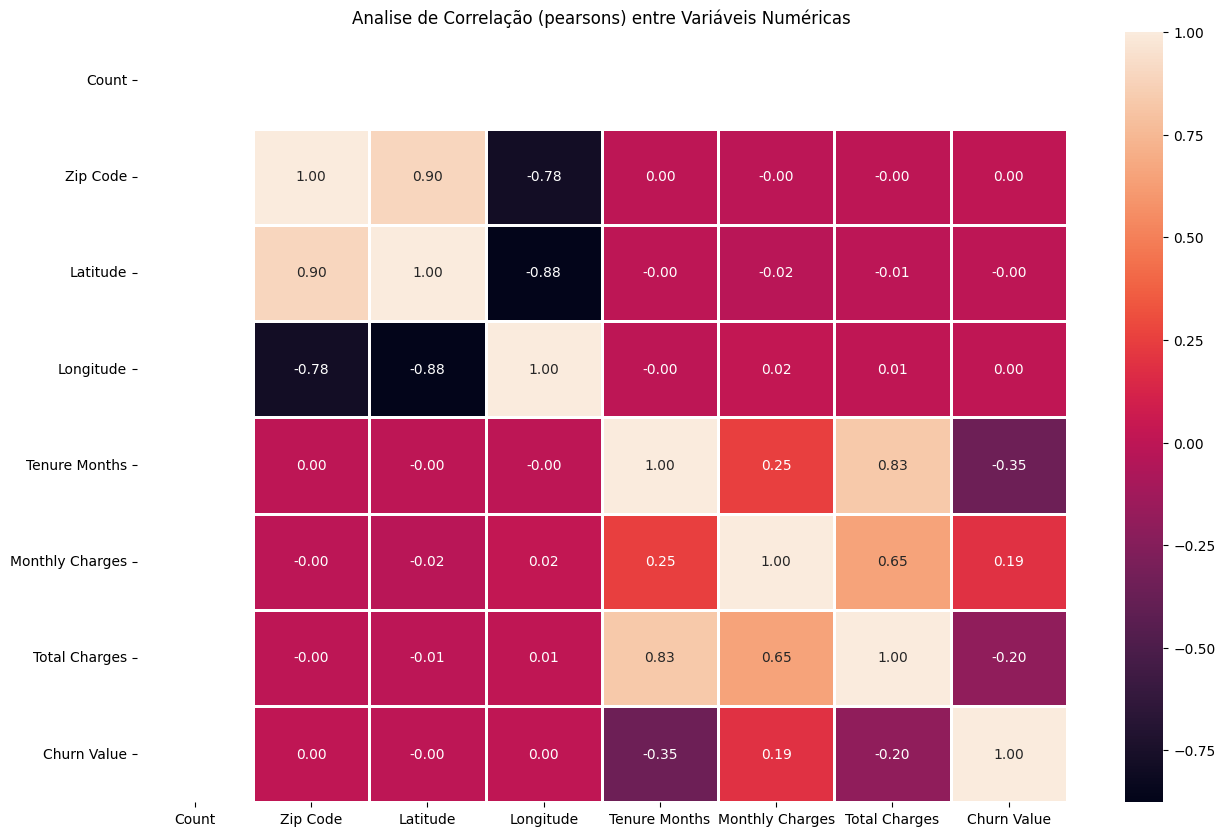

In [63]:
plt.figure(figsize=(15, 10))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', linewidths=2)
plt.title('Analise de Correlação (pearsons) entre Variáveis Numéricas')
plt.show()

### Correlação de pearsons entre as variáveis numéricas do nosso dataset, o mais importante aqui é observar a correlação entre elas e o churn value, podemos observar por exemplo que a variável tenure months que representa o tempo de permanência de um cliente reduz churn enquanto a variável monthly charges aumenta o churn.

In [64]:
df = df.drop(columns=[
    "Zip Code",
    "Latitude", 
    "Longitude", 
    "Count",
    "CustomerID",
    "Country",
    "City",
    "State",
    "Monthly Charges Bin", 
    "Total Charges Bin",
    "Lat Long" 
])

##### Colunas a serem removidas pois se apresentaram ser irrelevantes para a natureza do negócio além de algumas não apresentarem correlação nenhuma com o churn value, apagando tambem colunas que foram adicionadas durante a EDA para construção dos gráficos.

# Conclusão
A análise exploratória permitiu identificar padrões relevantes associados ao churn, destacando o impacto de fatores como tempo de permanência, valor mensal e tipo de contrato.
Assim sendo os principais fatores de churn que serão priorizados na modelagem: Tempo de permanência (Tenure) – fator mais relevante, tipo de contrato – contratos mensais aumentam churn, monthly charges – valores altos aumentam churn, total charges – indicador indireto de retenção.

In [65]:
df.to_csv("../data/processed/telco_clean.csv", index=False)

##### Salvando o dataset preprocessado, mantemos o dataset original na pasta data/raw